In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


Class labels: ['malignant' 'benign']

--- Random Forest Performance (Threshold: 0.85) ---
Accuracy: 92.98%
Precision (Low False Positives): 100.00%


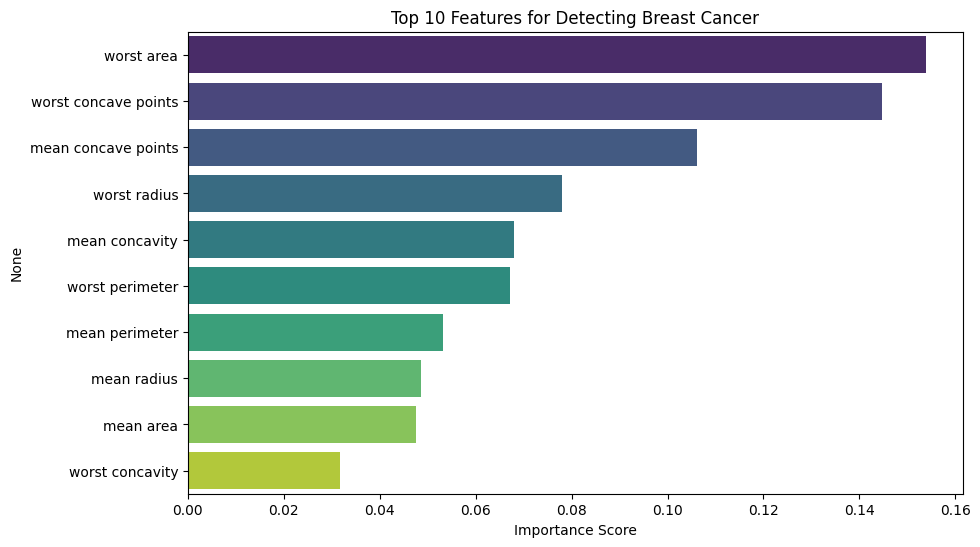

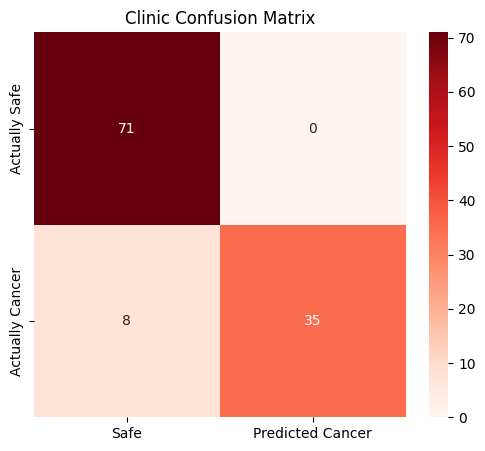

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

# 1. Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Prepare Data
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest Model
# n_estimators=100 means we build 100 different trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. "Clinic Mode" - Minimizing False Positives
# Instead of a simple yes/no, we get the PROBABILITY of cancer
y_probs = rf_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (Malignant) [See Note below]

# NOTE: Sklearn default: 0=Malignant, 1=Benign.
# If we want to detect Malignant (0), we usually look at prob of 0.
# Let's verify the classes:
print(f"Class labels: {data.target_names}") 
# (Usually ['malignant' 'benign'])

# LOGIC ADJUSTMENT: 
# If target=0 is Malignant, we want the probability of class 0.
y_probs_malignant = rf_model.predict_proba(X_test)[:, 0]

# SET THRESHOLD
# We only flag "Cancer" if the model is 85% sure (High Precision)
threshold = 0.85
y_pred_clinic = (y_probs_malignant > threshold).astype(int)

# Invert y_test for comparison (since 0 was Malignant, let's make 1=Detected Cancer for metrics)
y_test_binary = (y_test == 0).astype(int) 

# 5. Evaluate
print(f"\n--- Random Forest Performance (Threshold: {threshold}) ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_clinic)*100:.2f}%")
print(f"Precision (Low False Positives): {precision_score(y_test_binary, y_pred_clinic)*100:.2f}%")

# 6. Feature Importance (Why did the doctor decide this?)
feature_importance = pd.Series(rf_model.feature_importances_, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# FIXED LINE BELOW: We assign 'hue' to the y-variable and turn off the legend
sns.barplot(
    x=feature_importance.head(10), 
    y=feature_importance.head(10).index, 
    hue=feature_importance.head(10).index,  # fix for the warning
    legend=False,                           # fix for the warning
    palette='viridis'
)

plt.title('Top 10 Features for Detecting Breast Cancer')
plt.xlabel('Importance Score')
plt.show()

# 7. Confusion Matrix
cm = confusion_matrix(y_test_binary, y_pred_clinic)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Safe', 'Predicted Cancer'], yticklabels=['Actually Safe', 'Actually Cancer'])
plt.title('Clinic Confusion Matrix')
plt.show()

In [3]:
# --- NEW CELL: UPGRADING THE MODEL ---
from sklearn.model_selection import GridSearchCV

# 1. Define the "study plan" (Grid)
# We test different depths and numbers of trees to find the smartest one
param_grid = {
    'n_estimators': [100, 200],      # Try 100 vs 200 trees
    'max_depth': [None, 10, 20],     # Try unlimited depth vs limited
    'min_samples_split': [2, 5],     # Minimum samples required to split a node
    'class_weight': ['balanced', None] # 'balanced' helps if cancer cases are rare
}

print("Training the Super Model... please wait...")

# 2. Run the tests (GridSearch)
# This replaces the simple 'rf_model.fit' line
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=param_grid, 
    cv=3,         # Cross-validation: Check everything 3 times
    n_jobs=-1,    # Use all CPU cores for speed
    verbose=1
)

grid_search.fit(X_train, y_train)

# 3. THE IMPORTANT PART (The Switch)
# We take the winner and save it as 'rf_model'
# This tricks your OLD code below into using the NEW smart model automatically!
rf_model = grid_search.best_estimator_

print(f"Upgrade Complete! Best Settings: {grid_search.best_params_}")
print("You can now run the next cells (Confusion Matrix/Plots) without changing them.")

Training the Super Model... please wait...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Upgrade Complete! Best Settings: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
You can now run the next cells (Confusion Matrix/Plots) without changing them.


--- Final Clinic Model Performance (Threshold: 0.85) ---
Accuracy: 92.11%
Precision (Avoiding False Alarms): 100.00%


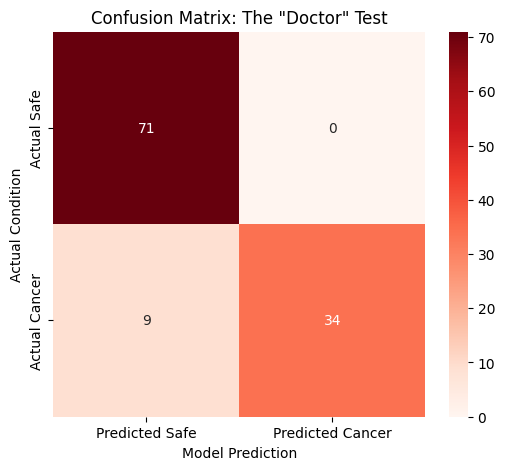

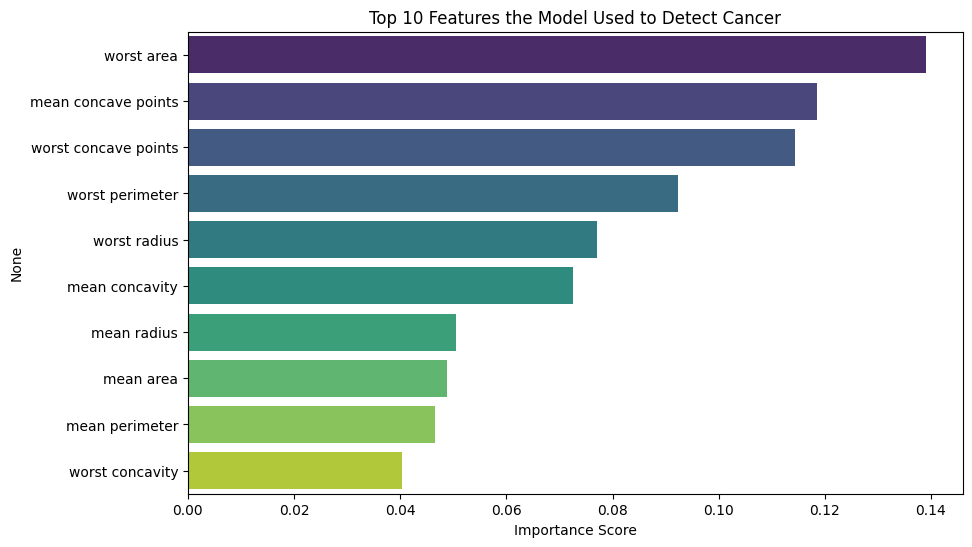

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, classification_report

# --- 1. CLINIC MODE: STRICT PREDICTIONS ---
# Get the probability that the patient has cancer (Class 0 in this dataset is Malignant)
# We use the probability of Class 0 (Malignant)
y_probs_malignant = rf_model.predict_proba(X_test)[:, 0]

# Set your "Safety Threshold"
# 0.85 means: "Only say it's cancer if you are 85% sure."
threshold = 0.85
y_pred_clinic = (y_probs_malignant > threshold).astype(int)

# Flip y_test so 1 = Cancer (for easier reading of metrics)
y_test_binary = (y_test == 0).astype(int)

# --- 2. PRINT RESULTS ---
print(f"--- Final Clinic Model Performance (Threshold: {threshold}) ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_clinic)*100:.2f}%")
print(f"Precision (Avoiding False Alarms): {precision_score(y_test_binary, y_pred_clinic)*100:.2f}%")

# --- 3. PLOT CONFUSION MATRIX ---
cm = confusion_matrix(y_test_binary, y_pred_clinic)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Safe', 'Predicted Cancer'],
            yticklabels=['Actual Safe', 'Actual Cancer'])
plt.title('Confusion Matrix: The "Doctor" Test')
plt.ylabel('Actual Condition')
plt.xlabel('Model Prediction')
plt.show()

# --- 4. PLOT FEATURE IMPORTANCE (Why did it decide?) ---
# This chart helps you explain the logic in your Viva
feature_importance = pd.Series(rf_model.feature_importances_, index=data.feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, legend=False, palette='viridis')
plt.title('Top 10 Features the Model Used to Detect Cancer')
plt.xlabel('Importance Score')
plt.show()

In [5]:
# --- STEP 6: THE CLINIC INTERFACE (FIXED) ---

def predict_patient_condition(patient_data):
    # 1. Prepare the data
    # We reshape to (1, -1) because it's just one patient, not a list
    # NOTE: We removed 'scaler' because your Random Forest was trained on raw data.
    patient_reshaped = np.array(patient_data).reshape(1, -1)
    
    # 2. Get the probability
    probability = rf_model.predict_proba(patient_reshaped)[0, 0] # Prob of Malignant
    
    # 3. Apply your Strict Rule
    prediction = "HIGH RISK (Malignant)" if probability > 0.85 else "Low Risk (Benign)"
    
    print(f"--- Patient Report ---")
    print(f"Cancer Probability: {probability*100:.2f}%")
    print(f"Final Diagnosis: {prediction}")
    
    if probability > 0.85:
        print("ACTION: Schedule biopsy immediately.")
    else:
        print("ACTION: Routine checkup recommended.")

# --- TEST IT ---
# Let's pick a real patient from our test set
# We select the first patient (row 0)
print("Testing with a real patient's data from our records...")
real_patient = X_test.iloc[0].values 

predict_patient_condition(real_patient)

Testing with a real patient's data from our records...
--- Patient Report ---
Cancer Probability: 5.00%
Final Diagnosis: Low Risk (Benign)
ACTION: Routine checkup recommended.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [6]:
import joblib

# 1. Save the model to a file
joblib.dump(rf_model, 'cancer_model.pkl')

print("Success! Download 'cancer_model.pkl' from the Output section.")

Success! Download 'cancer_model.pkl' from the Output section.
